# Region Coverage Validation: Sentinel-2

The other validation notebooks test TAT-C's observations of points. This notebook tests its observations of regions, with `collect_region_observations` and `collect_multi_region_observations`: a region (a polygon or multipolygon) is observed while any part of it lies within the instrument's field of regard. The reference is the acquisitions of the Copernicus [Sentinel-2](https://sentiwiki.copernicus.eu/web/s2-mission) Multispectral Instrument (MSI) over six countries during one of the constellation's 10-day repeat cycles, from 14 to 24 September 2026, by Sentinel-2B and 2C, whose acquisition plans include every pass over land (Sentinel-2A's reduced plan does not; see the [Sentinel-2 revisit](ValidateRevisitSentinel2.ipynb) notebook). The countries exercise the handling of region geometry:

* **Iceland**, a single polygon at high latitude;
* **Japan**, a multipolygon of islands;
* **Chile**, a long, narrow region spanning 38 deg of latitude (with Tierra del Fuego);
* **Fiji**, a multipolygon across the anti-meridian;
* **Norway**, a multipolygon reaching 80.7 deg north (with Svalbard); and
* **Switzerland**, a small landlocked region, narrower than the swath is long.

The comparison asks three questions:

1. **Passes.** Does `collect_multi_region_observations` predict the passes on which each satellite imaged any part of each region?
2. **Periods.** Do the observation periods start and end when the instrument's footprint first and last intersects the region?
3. **Revisit.** Do the sample counts and revisit periods from `aggregate_observations` and `reduce_observations` match those observed?

## Reference Data

The [Microsoft Planetary Computer](https://planetarycomputer.microsoft.com/dataset/sentinel-2-l2a) catalog of Sentinel-2 Level 2A products (anonymous access) is searched for every product whose valid data footprint intersects each region during the analysis period. Each product is a 110 km tile of one acquisition (datatake); the datatake identifies the satellite and the time at which the acquisition started (the catalog does not record the time each part of a region was imaged). An observed pass of a region is a datatake with at least one product intersecting it. The regions are the Natural Earth 1:110 million country polygons, whose coastlines are accurate to a few kilometers. Search results are cached in a local `data/sentinel2` directory.

The satellites are modeled with TLEs from [CelesTrak](https://celestrak.org/) whose epochs (4 October 2026) follow the end of the analysis period by 10 days; the revisit notebook finds that, propagated 20 days back, these TLEs are within 11 km (2B) and 3 km (2C) of the satellites' GPS positions.

In [1]:
import json
import time
from datetime import datetime, timedelta, timezone
from pathlib import Path

import cartopy.io.shapereader as shpreader
import numpy as np
import pandas as pd
import requests

DATA_DIR = Path("data") / "sentinel2"
DATA_DIR.mkdir(parents=True, exist_ok=True)
START = datetime(2026, 9, 14, tzinfo=timezone.utc)
END = datetime(2026, 9, 24, tzinfo=timezone.utc)
STAC = "https://planetarycomputer.microsoft.com/api/stac/v1/search"
TLES = {
    "Sentinel-2B": [
        "1 42063U 17013A   26277.50820593  .00000133  00000+0  67483-4 0  9991",
        "2 42063  98.5691 350.7118 0001149  89.0927 271.0388 14.30818478500277",
    ],
    "Sentinel-2C": [
        "1 60989U 24157A   26277.47326514  .00000038  00000+0  31260-4 0  9993",
        "2 60989  98.5703 350.6835 0001156  81.8213 278.3101 14.30817151108611",
    ],
}
PLATFORMS = list(TLES)
REGION_NAMES = ["Iceland", "Japan", "Chile", "Fiji", "Norway", "Switzerland"]

countries = shpreader.Reader(shpreader.natural_earth(resolution="110m", category="cultural", name="admin_0_countries"))
regions = {r.attributes["NAME"]: r.geometry for r in countries.records() if r.attributes["NAME"] in REGION_NAMES}
regions = {name: regions[name] for name in REGION_NAMES}
REGION_IDS = {name: i for i, name in enumerate(REGION_NAMES)}


def search(name, region):
    """Catalog products whose valid data footprint intersects a region during the analysis period."""
    cache = DATA_DIR / f"region_search_{name}_{START:%Y%m%d}_{END:%Y%m%d}.json"
    if cache.exists():
        return json.loads(cache.read_text())
    body = {
        "collections": ["sentinel-2-l2a"],
        "intersects": region.__geo_interface__,
        "datetime": f"{START:%Y-%m-%dT%H:%M:%SZ}/{END - timedelta(seconds=1):%Y-%m-%dT%H:%M:%SZ}",
        "limit": 1000,
        "fields": {"include": ["id", "properties.platform", "properties.s2:datatake_id"], "exclude": ["geometry"]},
    }
    rows = []
    while body is not None:
        for attempt in range(8):
            try:
                response = requests.post(STAC, json=body, timeout=300)
                response.raise_for_status()
                page = response.json()
                break
            except (requests.RequestException, ValueError):
                if attempt == 7:
                    raise
                # back off (the catalog limits request rates)
                time.sleep(2**attempt)
        rows += [
            {"region": name, "product": f["id"], "platform": f["properties"]["platform"], "datatake": f["properties"]["s2:datatake_id"]}
            for f in page["features"]
        ]
        following = [link for link in page.get("links", []) if link.get("rel") == "next"]
        body = following[0].get("body") if following else None
    cache.write_text(json.dumps(rows))
    return rows


products = pd.DataFrame([row for name, region in regions.items() for row in search(name, region)])
products["datatake_start"] = pd.to_datetime(products.datatake.str.extract(r"_(\d{8}T\d{6})_")[0], format="%Y%m%dT%H%M%S", utc=True)
observed = (
    products[products.platform.isin(PLATFORMS)]
    .groupby(["region", "platform", "datatake"], as_index=False)
    .agg(datatake_start=("datatake_start", "first"), products=("product", "size"))
    .sort_values(["region", "datatake_start"], ignore_index=True)
)
products.groupby(["region", "platform"]).agg(products=("product", "size"), passes=("datatake", "nunique")).unstack(fill_value=0).reindex(REGION_NAMES)

products                              passes              \
platform    Sentinel-2A Sentinel-2B Sentinel-2C Sentinel-2A Sentinel-2B   
region                                                                    
Iceland              84          84          83           7           7   
Japan                68         154         152           3           7   
Chile               173         299         279           4           7   
Fiji                  0          14          13           0           2   
Norway              566         570         503          33          32   
Switzerland          28          29          31           4           4   

                         
platform    Sentinel-2C  
region                   
Iceland               7  
Japan                 7  
Chile                 7  
Fiji                  2  
Norway               28  
Switzerland           4

## Setup

MSI images a 290 km swath, spanning cross-track view angles of about -10.55 to +10.55 deg. `collect_region_observations` considers only an instrument's field of regard (a cone about nadir), so MSI is modeled as an `Instrument` with a 21.1 deg field of regard: as the satellite moves, the cone sweeps the swath. It requires the target to be sunlit (`req_target_sunlit`), evaluated at the region's point nearest to nadir at each observation's epoch, which excludes the night-side passes.

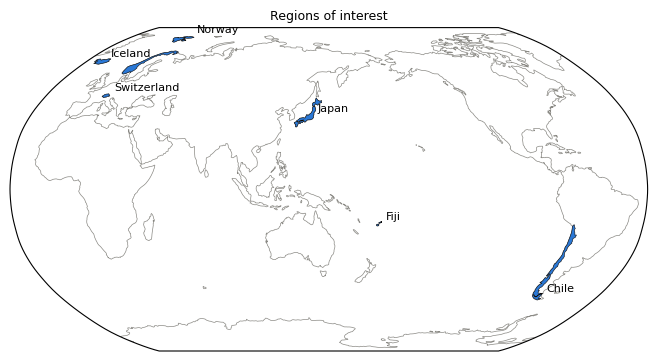

In [2]:
import cartopy.crs as ccrs
import geopandas as gpd
import matplotlib.pyplot as plt

from tatc.analysis import aggregate_observations, collect_ground_track, collect_multi_region_observations, reduce_observations
from tatc.schemas import GeneralPerturbationsOrbit, Instrument, Satellite

msi = Instrument(name="MSI", field_of_regard=21.1, req_target_sunlit=True)
satellites = {name: Satellite(name=name, orbit=GeneralPerturbationsOrbit.from_tle(tle), instruments=[msi]) for name, tle in TLES.items()}


def summarize(x):
    """Summary statistics of a residual sample."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return pd.Series({"n": x.size, "median": np.median(x), "p95 |x|": np.percentile(np.abs(x), 95), "max |x|": np.abs(x).max()})


BLUE, ORANGE, AQUA, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b"
PLATFORM_COLORS = dict(zip(PLATFORMS, [ORANGE, AQUA]))
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e0",
        "grid.linewidth": 0.6,
    }
)

fig = plt.figure(figsize=(12, 4.2))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=150))
ax.set_global()
ax.coastlines(color=GRAY, linewidth=0.5)
ax.add_geometries(list(regions.values()), crs=ccrs.PlateCarree(), facecolor=BLUE, edgecolor=INK, linewidth=0.4)
for name, region in regions.items():
    point = region.representative_point()
    ax.annotate(name, (point.x, point.y), xytext=(6, 4), textcoords="offset points", fontsize=8, transform=ccrs.PlateCarree())
ax.set_title("Regions of interest", fontsize=9)
plt.show()

## Test 1: Passes

`collect_multi_region_observations` predicts the observations of each region by each satellite. A region may be observed more than once on one pass, as the swath crosses separate parts of it (such as islands) with gaps between them, so consecutive observations by the same satellite less than 10 minutes apart (a satellite's consecutive passes are 100 minutes apart) are grouped into a predicted pass. A predicted pass matches an observed pass if it is by the same satellite and the datatake started no more than 45 minutes before the predicted pass began (the longest day-side datatakes last about 40 minutes) and no more than 1 minute after it ended.

In [3]:
def predict(instrument=msi):
    """Predicted observations of each region by each satellite, grouped into passes."""
    members = [s.model_copy(update={"instruments": [instrument]}) for s in satellites.values()]
    frames = []
    for name, region in regions.items():
        o = collect_multi_region_observations(region, members, START, END, omit_solar=False)
        frames.append(o.assign(region=name).rename(columns={"satellite": "platform"}))
    o = pd.concat(frames, ignore_index=True).sort_values(["region", "platform", "start"], ignore_index=True)
    new_pass = (o.region != o.region.shift()) | (o.platform != o.platform.shift()) | (o.start - o.end.shift() > pd.Timedelta(minutes=10))
    o["pass"] = new_pass.cumsum()
    return o


def passes(o):
    """Predicted passes: the span of each group of observations."""
    return o.groupby("pass").agg(
        region=("region", "first"), platform=("platform", "first"), start=("start", "min"), end=("end", "max"),
        observations=("epoch", "size"), solar_alt=("solar_alt", "max"),
    ).reset_index()


def match(predicted_passes):
    """Match predicted passes to observed passes (datatakes) of the same region and satellite."""
    pairs = predicted_passes.merge(observed, on=["region", "platform"])
    pairs = pairs[(pairs.datatake_start >= pairs.start - pd.Timedelta(minutes=45)) & (pairs.datatake_start <= pairs.end + pd.Timedelta(minutes=1))]
    p = predicted_passes.assign(acquired=predicted_passes["pass"].isin(pairs["pass"]))
    o = observed.assign(predicted=observed.set_index(["region", "datatake"]).index.isin(pairs.set_index(["region", "datatake"]).index))
    return p, o


predicted = predict()
predicted_passes, observed1 = match(passes(predicted))
table1 = pd.DataFrame(
    {
        "observed passes": observed1.groupby("region").size(),
        "observed passes predicted": observed1.groupby("region").predicted.sum(),
        "predicted passes": predicted_passes.groupby("region").size(),
        "predicted passes acquired": predicted_passes.groupby("region").acquired.sum(),
        "predicted observations": predicted.groupby("region").size(),
    }
).reindex(REGION_NAMES).fillna(0).astype(int)
table1.loc["total"] = table1.sum()
table1

,observed passes,observed passes predicted,predicted passes,predicted passes acquired,predicted observations
region,,,,,
Iceland,14,14,14,14,14
Japan,14,14,14,14,16
Chile,14,14,14,14,20
Fiji,4,4,4,4,4
Norway,60,60,87,58,91
Switzerland,8,8,8,8,8
total,114,114,141,112,153


Over the 10 days, Sentinel-2B and 2C imaged parts of the six regions on 114 passes, and TAT-C predicts every one of them, including those of Fiji, across the anti-meridian, and of Svalbard, at 80 deg north. Of TAT-C's 141 predicted passes, 112 were acquired: every predicted pass of Iceland, Japan, Chile, Fiji, and Switzerland, and 58 of Norway's 87.

On some passes, the swath crosses separate parts of a region, so the 141 predicted passes comprise 153 observations: 16 of Japan's islands on 14 passes, 20 of Chile on 14, and 91 of Norway (including Svalbard) on 87. Norway's 60 observed passes match 58 predicted passes because on two passes (by 2C on 15 September and by 2B on 20 September) the acquisition over Norway was split into two datatakes, about 4 minutes apart.

The predicted passes that were not acquired are classified, in order, as:

* **low Sun**: the solar elevation at the region's point nearest to nadir is below 10 deg (TAT-C's `req_target_sunlit` only requires it to be above 0 deg);
* **swath edge**: the pass is not predicted with a field of regard of 20.4 deg, the swath in which all bands have valid data (290 km); and
* **other**.

In [4]:
# swath edge: passes not predicted with the field of regard of the swath in
# which all bands have valid data (290 km, or +/-10.2 deg)
narrow = predict(Instrument(name="MSI (valid swath)", field_of_regard=20.4, req_target_sunlit=True))
narrow_passes = passes(narrow)
overlap = predicted_passes.merge(narrow_passes, on=["region", "platform"], suffixes=("", "_narrow"))
overlap = overlap[(overlap.start_narrow <= overlap.end) & (overlap.end_narrow >= overlap.start)]
predicted_passes["cause"] = "acquired"
missed = ~predicted_passes.acquired
predicted_passes.loc[missed & (predicted_passes.solar_alt < 10), "cause"] = "low Sun"
predicted_passes.loc[missed & (predicted_passes.cause == "acquired") & ~predicted_passes["pass"].isin(overlap["pass"]), "cause"] = "swath edge"
predicted_passes.loc[missed & (predicted_passes.cause == "acquired"), "cause"] = "other"
causes1 = predicted_passes.groupby(["region", "cause"]).size().unstack(fill_value=0).reindex(index=REGION_NAMES, columns=["acquired", "low Sun", "swath edge", "other"], fill_value=0)
causes1.loc["total"] = causes1.sum()
causes1

cause,acquired,low Sun,swath edge,other
region,,,,
Iceland,14,0,0,0
Japan,14,0,0,0
Chile,14,0,0,0
Fiji,4,0,0,0
Norway,58,29,0,0
Switzerland,8,0,0,0
total,112,29,0,0


In [5]:
# solar elevation (deg) at the region's point nearest to nadir, of acquired and other predicted passes
display(predicted_passes.groupby("cause").solar_alt.describe().round(1))
# predicted passes not acquired, and observed passes not predicted
display(predicted_passes[predicted_passes.cause != "acquired"][["region", "platform", "start", "end", "observations", "solar_alt", "cause"]])
display(observed1[~observed1.predicted][["region", "platform", "datatake", "datatake_start", "products"]])

,count,mean,std,min,25%,50%,75%,max
cause,,,,,,,,
acquired,112.0,27.9,16.7,5.4,11.8,26.4,43.5,61.1
low Sun,29.0,3.1,1.9,0.2,1.5,2.9,4.3,6.8


,region,platform,start,end,observations,solar_alt,cause
49,Norway,Sentinel-2B,2026-09-14 15:57:06.173553634+00:00,2026-09-14 15:58:06.038149686+00:00,1,4.246378,low Sun
50,Norway,Sentinel-2B,2026-09-14 17:36:25.749201746+00:00,2026-09-14 17:37:59.593647630+00:00,1,0.339881,low Sun
54,Norway,Sentinel-2B,2026-09-15 15:27:21.719031420+00:00,2026-09-15 15:28:11.967485901+00:00,1,5.053008,low Sun
55,Norway,Sentinel-2B,2026-09-15 17:06:44.095539195+00:00,2026-09-15 17:08:02.398551749+00:00,1,1.181370,low Sun
60,Norway,Sentinel-2B,2026-09-16 16:36:51.973199122+00:00,2026-09-16 16:38:04.023920845+00:00,1,1.739651,low Sun
64,Norway,Sentinel-2B,2026-09-17 16:07:02.743326993+00:00,2026-09-17 16:08:05.715953819+00:00,1,2.619647,low Sun
68,Norway,Sentinel-2B,2026-09-18 15:37:17.581791385+00:00,2026-09-18 15:38:10.685220405+00:00,1,3.468367,low Sun
72,Norway,Sentinel-2B,2026-09-19 15:07:30.796358845+00:00,2026-09-19 15:08:19.112114429+00:00,1,4.251019,low Sun
73,Norway,Sentinel-2B,2026-09-19 16:46:50.435418140+00:00,2026-09-19 16:48:04.759575559+00:00,1,0.242235,low Sun
77,Norway,Sentinel-2B,2026-09-20 16:16:59.561406019+00:00,2026-09-20 16:18:05.300312740+00:00,1,0.966521,low Sun


,region,platform,datatake,datatake_start,products


All 29 predicted passes that were not acquired are of Norway, between 13:57 and 17:37 UTC, when the Sun at the region's point nearest to nadir was 0.2 to 6.8 deg above the horizon; the acquired passes had solar elevations of 5.4 to 61 deg. As in the [Sentinel-2 revisit](ValidateRevisitSentinel2.ipynb) notebook, Sentinel-2's acquisition plan does not image at such a low Sun, which `req_target_sunlit` does not model. A minimum target solar elevation (`min_target_solar_elevation`) would remove these passes, but not cleanly: for a region, it is evaluated only at the point nearest to nadir at the epoch, and three acquired passes had solar elevations below 7 deg there. No predicted pass was missed at the swath edge or otherwise, and every observed pass was predicted.

## Test 2: Periods

The catalog does not record when each part of a region was imaged, so the observation periods are compared with TAT-C's own footprints, computed independently (by projecting the field of regard onto the WGS 84 ellipsoid) with `collect_ground_track`, with each region as a mask. Footprints are sampled every 0.1 s within 5 s of each observation's start and end, and the first and last footprints that intersect the region are compared with the start and end. (A footprint is a polygon inscribed in the field of regard's circle, so it reaches a region slightly later and leaves slightly earlier than the field of regard.)

In [6]:
def footprint_times(row, center):
    """Times, at 0.1 s intervals within 5 s of a time, at which the footprint intersects the region."""
    times = pd.date_range(center - pd.Timedelta(seconds=5), center + pd.Timedelta(seconds=5), freq="100ms").to_pydatetime().tolist()
    return collect_ground_track(satellites[row.platform], times, mask=regions[row.region]).time


def footprint_period(row):
    """First footprint intersecting the region near the start, and last near the end."""
    first, last = footprint_times(row, row.start), footprint_times(row, row.end)
    return pd.Series({"first": first.min() if len(first) else pd.NaT, "last": last.max() if len(last) else pd.NaT})


periods2 = pd.concat([predicted, predicted.apply(footprint_period, axis=1)], axis=1)
periods2["start difference (s)"] = (periods2["first"] - periods2.start).dt.total_seconds()
periods2["end difference (s)"] = (periods2.end - periods2["last"]).dt.total_seconds()
periods2["duration (s)"] = (periods2.end - periods2.start).dt.total_seconds()
print("observations without an intersecting footprint:", int(periods2["first"].isna().sum()))
pd.DataFrame({column: summarize(periods2[column]) for column in ["duration (s)", "start difference (s)", "end difference (s)"]}).T

observations without an intersecting footprint: 0


,n,median,p95 |x|,max |x|
duration (s),153.0,79.232888,264.258970,553.000094
start difference (s),153.0,0.100000,0.299999,0.699999
end difference (s),153.0,0.100001,0.200001,0.700000


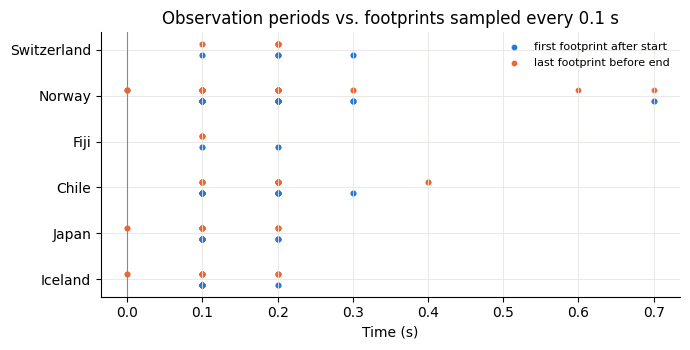

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for k, (name, frame) in enumerate(periods2.groupby("region", sort=False)):
    y = np.full(len(frame), REGION_IDS[name])
    ax.scatter(frame["start difference (s)"], y - 0.12, s=10, color=BLUE, label="first footprint after start" if k == 0 else None)
    ax.scatter(frame["end difference (s)"], y + 0.12, s=10, color=ORANGE, label="last footprint before end" if k == 0 else None)
ax.set_yticks(range(len(REGION_NAMES)), REGION_NAMES)
ax.axvline(0, color=GRAY, lw=0.8)
ax.set(xlabel="Time (s)", title="Observation periods vs. footprints sampled every 0.1 s")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

Every one of the 153 predicted observations, which last from 20 s to 9.2 minutes, has footprints intersecting the region near its start and end. The first footprint that intersects the region follows the observation's start by 0.1 s (median; at most 0.7 s), and the last precedes its end by 0.1 s (median; at most 0.7 s), never the other way around: the observation periods agree with the footprints within the 0.1 s sampling and the inscribed footprint polygon's slightly smaller extent, for every region geometry.

## Test 3: Revisit

For each region, the observed passes (at their datatake start times) and the predicted passes (at their midpoints) are aggregated with `aggregate_observations` and reduced with `reduce_observations` to a number of samples and a mean revisit period. Each region's observations carry its geometry, by which, with its identifier, the observations are grouped. Because the datatake start precedes the imaging time by up to 40 minutes, revisit periods are compared in days.

In [8]:
def as_observations(frame, time_column):
    """A data frame of instantaneous observations of regions, as accepted by aggregate_observations."""
    t = frame[time_column]
    return gpd.GeoDataFrame(
        {
            "point_id": frame.region.map(REGION_IDS).to_numpy(),
            "geometry": [regions[name] for name in frame.region],
            "satellite": frame.platform.to_numpy(),
            "instrument": "MSI",
            "start": t.to_numpy(),
            "epoch": t.to_numpy(),
            "end": t.to_numpy(),
        },
        crs="EPSG:4326",
    )


def revisit_statistics(frame):
    reduced = reduce_observations(aggregate_observations(frame))
    reduced["region"] = reduced.point_id.map({i: name for name, i in REGION_IDS.items()})
    reduced["revisit (days)"] = reduced.revisit.dt.total_seconds() / 86400
    return reduced.set_index("region")[["samples", "revisit (days)"]].reindex(REGION_NAMES)


midpoints = predicted_passes.assign(midpoint=predicted_passes.start + (predicted_passes.end - predicted_passes.start) / 2)
o3 = revisit_statistics(as_observations(observed1, "datatake_start"))
p3 = revisit_statistics(as_observations(midpoints, "midpoint"))
a3 = revisit_statistics(as_observations(midpoints[midpoints.acquired], "midpoint"))
pd.concat({"observed": o3, "predicted": p3, "predicted, acquired passes": a3}, axis=1).round(2)

observed                predicted                 \
             samples revisit (days)   samples revisit (days)   
region                                                         
Iceland           14           0.69        14           0.69   
Japan             14           0.69        14           0.69   
Chile             14           0.69        14           0.69   
Fiji               4           2.67         4           2.67   
Norway            60           0.15        87           0.11   
Switzerland        8           1.29         8           1.29   

            predicted, acquired passes                 
                               samples revisit (days)  
region                                                 
Iceland                             14           0.69  
Japan                               14           0.69  
Chile                               14           0.69  
Fiji                                 4           2.67  
Norway                              58           0.16  
Switzerland                          8           1.29

For Iceland, Japan, Chile, Fiji, and Switzerland, the predicted sample counts and mean revisit periods equal those observed: 14 samples with a mean revisit of 0.69 days for each of Iceland, Japan, and Chile, 8 samples and 1.29 days for Switzerland, and 4 samples and 2.67 days for Fiji. For Norway, TAT-C predicts 87 samples with a mean revisit of 0.11 days, against 60 observed with 0.15 days: the difference is the 29 low-Sun passes. Restricted to the predicted passes that were acquired, the prediction is 58 samples and 0.16 days (the two remaining observed samples are the second datatakes of split acquisitions).

## Summary

| Test | Result |
| --- | --- |
| 1. Passes (`collect_multi_region_observations`) | all 114 observed passes of the six regions predicted; 112 of 141 predicted passes acquired; the other 29, all of Norway, at solar elevations of 0.2 to 6.8 deg, below Sentinel-2's acquisition plan |
| 2. Periods | observation starts and ends within 0.1 s (median) and 0.7 s (maximum) of the first and last footprints intersecting each region, sampled every 0.1 s |
| 3. Revisit (`aggregate_observations`, `reduce_observations`) | sample counts and mean revisit periods equal to those observed for five of six regions; Norway's 87 predicted samples (60 observed) include the 29 low-Sun passes |

`collect_region_observations` predicts when Sentinel-2 images any part of a region, for single polygons and multipolygons, across the anti-meridian, and at high latitude, with observation periods consistent with the instrument's footprints. As for points, its predictions assume that every pass in view is acquired: here, with Sentinel-2's acquisition plan, every sunlit pass except at a low Sun.